# Making Predictions with Linear Regression in Statsmodels

In earlier sections, we focused on **estimating coefficients** in a linear regression model. Those coefficients help us describe the relationship between the input variable and the output variable.

But predictive analytics is not only about describing relationships.

In this notebook, we will use a fitted linear regression model to make predictions on a new set of input values and then visualize those predictions. This is a way to not only get predictions for specific input values, but also understand how our model behaves across a variety of input.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np

## Dataset

For the data, we will use the food truck data on profits and the population of cities used in this module.

In [2]:
profits = pd.read_csv('https://raw.githubusercontent.com/girishkuniyal/Predict-Profit-for-food-truck/refs/heads/master/ex1data1.txt',
                    header = None,
                    names = ['population', 'profit'])

profits.info()
profits.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  97 non-null     float64
 1   profit      97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB


,population,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


## Step 1: Create a Visualization Grid

To visualize predictions clearly, we create a new dataset containing many evenly spaced input values. This is often called as a prediction visualization grid.

We slightly extend the range beyond the training data so the trend is easier to see.

In [3]:
viz_input = np.linspace(profits.population.min() - 0.1, profits.population.max() + 0.1, num=101)
viz_input

array([ 4.9269  ,  5.100661,  5.274422,  5.448183,  5.621944,  5.795705,
        5.969466,  6.143227,  6.316988,  6.490749,  6.66451 ,  6.838271,
        7.012032,  7.185793,  7.359554,  7.533315,  7.707076,  7.880837,
        8.054598,  8.228359,  8.40212 ,  8.575881,  8.749642,  8.923403,
        9.097164,  9.270925,  9.444686,  9.618447,  9.792208,  9.965969,
       10.13973 , 10.313491, 10.487252, 10.661013, 10.834774, 11.008535,
       11.182296, 11.356057, 11.529818, 11.703579, 11.87734 , 12.051101,
       12.224862, 12.398623, 12.572384, 12.746145, 12.919906, 13.093667,
       13.267428, 13.441189, 13.61495 , 13.788711, 13.962472, 14.136233,
       14.309994, 14.483755, 14.657516, 14.831277, 15.005038, 15.178799,
       15.35256 , 15.526321, 15.700082, 15.873843, 16.047604, 16.221365,
       16.395126, 16.568887, 16.742648, 16.916409, 17.09017 , 17.263931,
       17.437692, 17.611453, 17.785214, 17.958975, 18.132736, 18.306497,
       18.480258, 18.654019, 18.82778 , 19.001541, 

This gives us 101 evenly spaced values of population (the input variable). It's often nice to specify a nice, round number (like 100) + 1 so that you get that round number of intervals. But here it doesn't matter as much since your minimum and maximum values are dependent on the data.

Let's create a DataFrame with these values as inputs:

In [4]:
df_viz = pd.DataFrame({'population': viz_input})
df_viz.head()

,population
0,4.926900
1,5.100661
2,5.274422
3,5.448183
4,5.621944


## Step 2: Making Predictions

The fitted statsmodels object includes a `.predict()` method.

This allows us to generate predictions for a new dataset using the learned model.

Note: we would use the original dataset (profits) for the training, not this visualization grid.

In [5]:
model = smf.ols(formula = 'profit ~ population', data = profits).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 profit   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     223.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.02e-26
Time:                        15:29:26   Log-Likelihood:                -243.95
No. Observations:                  97   AIC:                             491.9
Df Residuals:                      95   BIC:                             497.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.8958      0.719     -5.415      0.000      -5.324      -2.467
population     1.1930      0.080     14.961      0.000       1.035       1.351
==============================================================================
Omnibus:                       39.986   Durbin-Watson:                   0.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              108.142
Skew:                           1.455   Prob(JB):                     3.29e-24
Kurtosis:                       7.276   Cond. No.                         21.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
lm_pred = model.predict(df_viz)
lm_pred

0       1.982177
1       2.189479
2       2.396782
3       2.604085
4       2.811387
         ...    
96     21.883238
97     22.090540
98     22.297843
99     22.505146
100    22.712448
Length: 101, dtype: float64

This computes the predicted output for each value of population in df_viz(prediction visualization grid). As you can see, there are 101 values, just like we specified in the predicted visualization grid.

## Step 3: Storing Predictions

We can store the predictions alongside the input values for easier visualization.

In [7]:
df_viz['pred_trend'] = lm_pred
df_viz.head()

,population,pred_trend
0,4.926900,1.982177
1,5.100661,2.189479
2,5.274422,2.396782
3,5.448183,2.604085
4,5.621944,2.811387


Here `population` refers to our evenly spaced input values and `pred_trend` is our model predictions for those corresponding inputs.

## Step 4: Visualizing the Predicted Trend

We can visualize how the predicted output changes with respect to the input.

This line represents the model’s predicted relationship. Just like a scatterplot, you can build a line plot in Seaborn with the figure-level `relplot` function and `kind=line`.

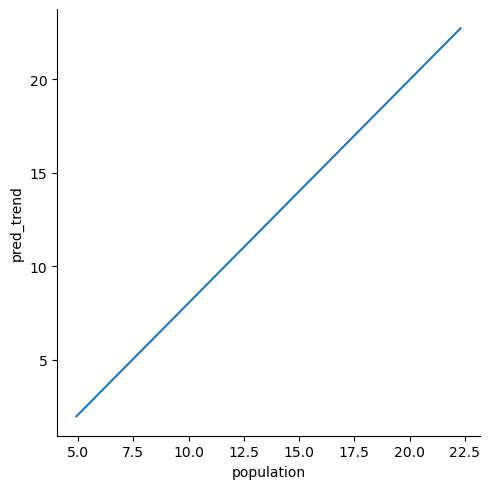

In [8]:
sns.relplot(data=df_viz, x='population', y='pred_trend', kind='line')
plt.show()

## Step 5: Adding Training Data

To better understand the model, we overlay the original training data. We will add a scatter plot of the original data onto the prediction line.

It's easiest to use Axes-level Seaborn functions to plot both the predictions and training datapoints on the same Axes object.

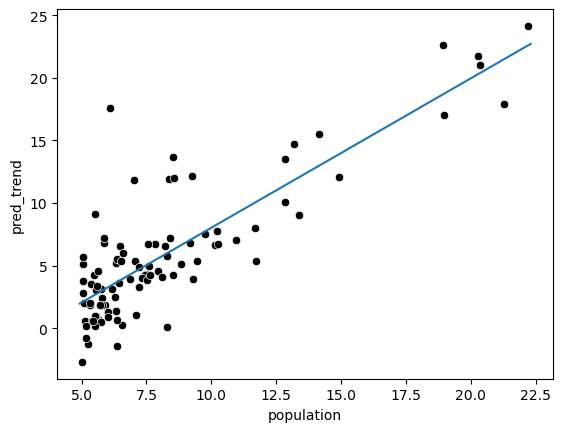

In [9]:
fig, ax = plt.subplots()
sns.lineplot(data=df_viz, x='population', y='pred_trend', ax=ax)
sns.scatterplot(data=profits, x='population', y='profit', color='black', ax=ax)

plt.show()

Here the black points are the actual observed training datapoints. The blue line is the predicted trend.

## Conclusion

- Linear regression can be used for prediction, not just interpretation.
- `.predict()` allows us to estimate outputs for new inputs.
- A prediction grid helps visualize model behavior.
- Overlaying training data helps evaluate how well the model fits.